# 01 数据资产盘点
读取仓库中的真实文件清单，统计文件类型、数量和大小。本 Notebook 不下载任何数据。

In [1]:
from pathlib import Path
import pandas as pd
import matplotlib.pyplot as plt

project = Path.cwd().parent if Path.cwd().name == 'notebooks' else Path.cwd()
manifest = pd.read_csv(project / 'metadata/files_manifest.csv', encoding='utf-8-sig')
manifest.head()

D:\anaconda\Lib\site-packages\pandas\core\computation\expressions.py:23: UserWarning: Pandas requires version '2.10.2' or newer of 'numexpr' (version '2.8.7' currently installed).
  from pandas.core.computation.check import NUMEXPR_INSTALLED
D:\anaconda\Lib\site-packages\pandas\core\arrays\masked.py:56: UserWarning: Pandas requires version '1.4.2' or newer of 'bottleneck' (version '1.3.7' currently installed).
  from pandas.core import (


,source_id,run_accession,experiment_accession,experiment_title,run_title,file_name,file_type,data_level,size_bytes,download_url,is_raw,is_processed,local_path,download_status,sha256,git_tracking,notes
0,HRA005567,HRR1375369,HRX1076971,CP1-1,CP1-1-a,HRR1375369_f1.fq.gz,FASTQ,raw,5009377565,https://download.cncb.ac.cn/gsa-human/HRA00556...,yes,no,data/raw/HRA005567/HRR1375369/HRR1375369_f1.fq.gz,not_downloaded,NaN,ignored,官方HTTPS目录；未下载
1,HRA005567,HRR1375369,HRX1076971,CP1-1,CP1-1-a,HRR1375369_r2.fq.gz,FASTQ,raw,11199674364,https://download.cncb.ac.cn/gsa-human/HRA00556...,yes,no,data/raw/HRA005567/HRR1375369/HRR1375369_r2.fq.gz,not_downloaded,NaN,ignored,官方HTTPS目录；未下载
2,HRA005567,HRR1375369,NaN,NaN,NaN,HRR1375369_sta.xml,XML,run_statistics,2381,https://download.cncb.ac.cn/gsa-human/HRA00556...,no,no,data/external/HRA005567/HRR1375369/HRR1375369_...,not_downloaded,NaN,ignored,官方run统计；未提交附件
3,HRA005567,HRR1375370,HRX1076971,CP1-1,CP1-1-b,HRR1375370_f1.fq.gz,FASTQ,raw,2297190750,https://download.cncb.ac.cn/gsa-human/HRA00556...,yes,no,data/raw/HRA005567/HRR1375370/HRR1375370_f1.fq.gz,not_downloaded,NaN,ignored,官方HTTPS目录；未下载
4,HRA005567,HRR1375370,HRX1076971,CP1-1,CP1-1-b,HRR1375370_r2.fq.gz,FASTQ,raw,5109464458,https://download.cncb.ac.cn/gsa-human/HRA00556...,yes,no,data/raw/HRA005567/HRR1375370/HRR1375370_r2.fq.gz,not_downloaded,NaN,ignored,官方HTTPS目录；未下载


In [2]:
summary = (manifest.groupby(['source_id', 'file_type'], dropna=False)
           .agg(file_count=('file_name', 'size'), size_bytes=('size_bytes', 'sum'))
           .reset_index())
summary['size_GiB'] = summary['size_bytes'] / 2**30
summary

,source_id,file_type,file_count,size_bytes,size_GiB
0,CELL_SUPPLEMENTS,XLSX,5,871504,8.116513e-04
1,HRA005567,FASTQ,256,1997710185424,1.860513e+03
2,HRA005567,XML,128,304237,2.833428e-04
3,ZENODO10851179,MD,1,14,1.303852e-08
4,ZENODO10851179,PY,7,8664,8.068979e-06
5,ZENODO10851179,R,3,3276,3.051013e-06
6,ZENODO10851179,SH,3,27526,2.563559e-05
7,ZENODO10851179,TXT,2,964,8.977950e-07


WindowsPath('C:/Users/l/Documents/Codex/2026-08-15/github/spatial-omics-literature-data/papers/xiao-2024-human-gastrulation/results/figures/hra_file_size_summary.png')

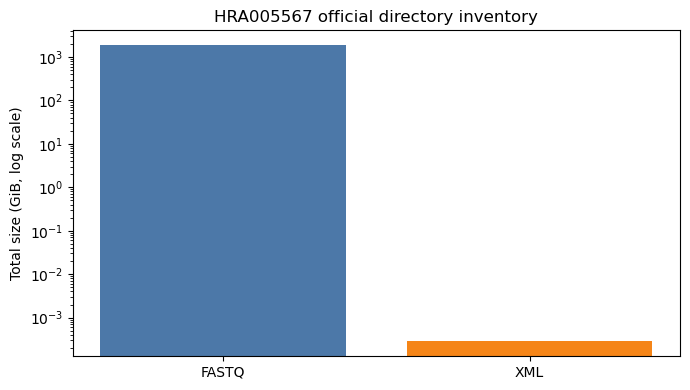

In [3]:
hra = summary[summary.source_id == 'HRA005567'].copy()
fig, ax = plt.subplots(figsize=(7, 4))
ax.bar(hra.file_type, hra.size_GiB, color=['#4C78A8', '#F58518'])
ax.set_ylabel('Total size (GiB, log scale)')
ax.set_title('HRA005567 official directory inventory')
ax.set_yscale('log')
fig.tight_layout()
out = project / 'results/figures/hra_file_size_summary.png'
fig.savefig(out, dpi=160)
out